# Ejercicios Entrevistas ML

### Ejercicio de entrevista: Preprocesamiento y modelado ML inicial

* 🧠 Contexto:
  - Eres parte del equipo de análisis de una tienda en línea.
  - Te dan un conjunto de datos que contiene información básica de clientes y su historial de compras.
  - Quieren que crees un modelo para predecir si un cliente realizará una nueva compra (compra_futura = 1) o no (compra_futura = 0).

* 📄 Datos de entrada:
``` python
np.random.seed(0)

n = 100

df = pd.DataFrame({
    "cliente_id": np.arange(1, n+1),
    "edad": np.random.randint(18, 65, size=n),
    "pais": np.random.choice(["MX", "CO", "AR", "CL", None], size=n, p=[0.3, 0.3, 0.2, 0.15, 0.05]),
    "genero": np.random.choice(["M", "F", None], size=n, p=[0.45, 0.5, 0.05]),
    "total_compras": np.random.randint(0, 20, size=n),
    "monto_promedio": np.round(np.random.normal(500, 100, size=n), 2),
    "compra_futura": np.random.choice([0, 1], size=n, p=[0.6, 0.4])
})
# Introducir algunos valores faltantes aleatorios en 'edad' y 'monto_promedio'
for col in ["edad", "monto_promedio"]:
    df.loc[df.sample(frac=0.05).index, col] = None
```
🧩 Tareas (en orden recomendado):
* Limpieza de datos:
  - Imputa los valores faltantes de edad y monto_promedio con la media.
  - Imputa los valores faltantes de pais y genero con la moda.

* Codificación:
  - Codifica las variables categóricas (pais, genero) con One-Hot Encoding.

* Escalamiento:
  - Escala las columnas numéricas (edad, total_compras, monto_promedio) usando MinMaxScaler.

* Separación:
  - Divide los datos en variables predictoras X y variable objetivo y.

* Entrenamiento:
  - Usa un modelo simple como LogisticRegression para entrenar el modelo.

* Evaluación:
  - Imprime la exactitud (accuracy) y la matriz de confusión.

In [26]:
import pandas as pd
import numpy as np

### Librerías Permitidas
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

### Información Proporcionada
np.random.seed(0)
n = 100
df = pd.DataFrame({
    "cliente_id": np.arange(1, n+1),
    "edad": np.random.randint(18, 65, size=n),
    "pais": np.random.choice(["MX", "CO", "AR", "CL", None], size=n, p=[0.3, 0.3, 0.2, 0.15, 0.05]),
    "genero": np.random.choice(["M", "F", None], size=n, p=[0.45, 0.5, 0.05]),
    "total_compras": np.random.randint(0, 20, size=n),
    "monto_promedio": np.round(np.random.normal(500, 100, size=n), 2),
    "compra_futura": np.random.choice([0, 1], size=n, p=[0.6, 0.4])
})
# Introducir algunos valores faltantes aleatorios en 'edad' y 'monto_promedio'
for col in ["edad", "monto_promedio"]:
    df.loc[df.sample(frac=0.05).index, col] = None

print("="*5, "Original", "="*5,"\n")
print(df.head(), "\n")

===== Original ===== 

   cliente_id  edad  pais genero  total_compras  monto_promedio  compra_futura
0           1  62.0    MX      F             15          602.47              1
1           2  18.0    AR      F              8          491.83              0
2           3  21.0    AR      F              3          237.25              0
3           4  21.0  None      M              6          464.35              0
4           5  57.0    CL      F             17          490.14              0 



* Podrías imprimir el número de valores nulos antes y después para tener trazabilidad. `print(df.isna().sum())`

In [21]:
### 1.1 Imputa los valores faltantes de edad y monto_promedio con la media.
df["edad"] = df["edad"].fillna(df["edad"].mean(skipna=True))
df["monto_promedio"] = df["monto_promedio"].fillna(df["monto_promedio"].mean(skipna=True))
### 1.2 Imputa los valores faltantes de pais y genero con la moda.
df["pais"] = df["pais"].fillna(df["pais"].mode(dropna=True)[0])
df["genero"] = df["genero"].fillna(df["genero"].mode(dropna=True)[0])
print("="*5, "1. Limpieza Datos", "="*5,"\n")
print(df, "\n")

===== 1. Limpieza Datos ===== 

    cliente_id  edad pais genero  total_compras  monto_promedio  compra_futura
0            1  62.0   MX      F             15      602.470000              1
1            2  18.0   AR      F              8      491.830000              0
2            3  21.0   AR      F              3      237.250000              0
3            4  21.0   CO      M              6      464.350000              0
4            5  57.0   CL      F             17      490.140000              0
..         ...   ...  ...    ...            ...             ...            ...
95          96  59.0   CO      M             19      563.130000              0
96          97  38.6   MX      F              6      310.560000              0
97          98  18.0   CO      M             10      499.880105              0
98          99  49.0   MX      F             19      468.750000              1
99         100  23.0   MX      F              2      581.420000              0

[100 rows x 7 colum

* Para evitar el problema de colinealidad perfecta, podrías usar: `OneHotEncoder(sparse_output=False, drop='first')`
* Es una comprensión de listas anidada, que construye los nombres de las columnas resultantes de tu codificación One-Hot.
``` python
# Crear nombres de columnas como pais_MX, genero_F, etc.
nombres_columnas = [
    f"{feature}_{categoria}"
    for feature, categorias in zip(["pais", "genero"], codificador.categories_)
    for categoria in categorias
]
```
* El atributo codificador.categories_ contiene una lista de las categorías encontradas por cada columna codificada. `[
    array(['AR', 'CL', 'CO', 'MX'], dtype=object),  # para 'pais'
    array(['F', 'M'], dtype=object)                 # para 'genero']`
* `zip(["pais", "genero"], codificador.categories_)`: Esto crea pares `("pais", ['AR', 'CL', 'CO', 'MX'])
("genero", ['F', 'M'])`

In [22]:
### 2. Codifica las variables categóricas (pais, genero) con One-Hot Encoding.
codificador = OneHotEncoder(sparse_output=False)  # <-- importante para obtener array directamente
codificacion = codificador.fit_transform(df[["pais", "genero"]])

# Crear nombres de columnas como pais_MX, genero_F, etc.
nombres_columnas = [
    f"{feature}_{categoria}"
    for feature, categorias in zip(["pais", "genero"], codificador.categories_)
    for categoria in categorias
]

# Crear nuevo DataFrame codificado
df_codificado = pd.DataFrame(codificacion, columns=nombres_columnas)

# Concatenar al original
df = pd.concat([df.reset_index(drop=True), df_codificado.reset_index(drop=True)], axis=1)
df.drop("pais", axis="columns", inplace=True)
df.drop("genero", axis="columns", inplace=True)
print("="*5, "2. Codificación", "="*5, "\n")
print(df.head())

===== 2. Codificación ===== 

   cliente_id  edad  total_compras  monto_promedio  compra_futura  pais_AR  \
0           1  62.0             15          602.47              1      0.0   
1           2  18.0              8          491.83              0      1.0   
2           3  21.0              3          237.25              0      1.0   
3           4  21.0              6          464.35              0      0.0   
4           5  57.0             17          490.14              0      0.0   

   pais_CL  pais_CO  pais_MX  genero_F  genero_M  
0      0.0      0.0      1.0       1.0       0.0  
1      0.0      0.0      0.0       1.0       0.0  
2      0.0      0.0      0.0       1.0       0.0  
3      0.0      1.0      0.0       0.0       1.0  
4      1.0      0.0      0.0       1.0       0.0  


* En casos reales, sería bueno usar stratify=y para mantener proporciones de clases iguales en train y test: `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`

In [23]:
### 3. Escala las columnas numéricas (edad, total_compras, monto_promedio) usando MinMaxScaler.
columnas_a_escalar = ["edad", "total_compras", "monto_promedio"]
df_escalado = df.copy()
escalador = MinMaxScaler()
df_escalado[columnas_a_escalar] = escalador.fit_transform(df_escalado[columnas_a_escalar])

print("=" * 5, "3. Datos Escalados", "=" * 5, "\n")
print(df_escalado.head())

===== 3. Datos Escalados ===== 

   cliente_id      edad  total_compras  monto_promedio  compra_futura  \
0           1  0.956522       0.789474        0.661648              1   
1           2  0.000000       0.421053        0.469277              0   
2           3  0.065217       0.157895        0.026637              0   
3           4  0.065217       0.315789        0.421497              0   
4           5  0.847826       0.894737        0.466339              0   

   pais_AR  pais_CL  pais_CO  pais_MX  genero_F  genero_M  
0      0.0      0.0      0.0      1.0       1.0       0.0  
1      1.0      0.0      0.0      0.0       1.0       0.0  
2      1.0      0.0      0.0      0.0       1.0       0.0  
3      0.0      0.0      1.0      0.0       0.0       1.0  
4      0.0      1.0      0.0      0.0       1.0       0.0  


* Esto no es una clase altamente desbalanceada, pero tampoco es perfectamente balanceada (50%-50%). Un modelo que predijera todo como clase 0 tendría 59% de accuracy, lo cual es un dato de referencia importante.

In [37]:
### 4. Divide los datos en variables predictoras X y variable objetivo y.
X = df_escalado.drop(columns=["cliente_id", "compra_futura"])
y = df_escalado["compra_futura"]
print("Distribución de clases en y:")
print(y.value_counts(normalize=True))
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state=42
)

Distribución de clases en y:
compra_futura
0    0.59
1    0.41
Name: proportion, dtype: float64


* `np.set_printoptions(suppress=True)`: en NumPy se utiliza para controlar cómo se muestran los números flotantes al imprimir arreglos NumPy.

In [40]:
### 5. Usa un modelo simple como LogisticRegression para entrenar el modelo.
modelo = LogisticRegression().fit(X_train, y_train)

* Hacer predicciones con el conjunto de prueba (X_test)
* Comparar esas predicciones con las verdaderas (y_test)
* Calcular la precisión (accuracy)
* Imprimir la matriz de confusión

In [39]:
### 6. Evaluación: Imprime la exactitud (accuracy) y la matriz de confusión.
# 1. Hacer predicciones
y_pred = modelo.predict(X_test)

# 2. Calcular exactitud (accuracy)
accuracy = accuracy_score(y_test, y_pred)

# 3. Calcular matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# 4. Imprimir resultados
print("="*5, "6. Evaluación del Modelo", "="*5)
print(f"Exactitud del modelo: {accuracy:.4f}")
print("Matriz de Confusión:")
print(matriz)

===== 6. Evaluación del Modelo =====
Exactitud del modelo: 0.3500
Matriz de Confusión:
[[ 7  3]
 [10  0]]


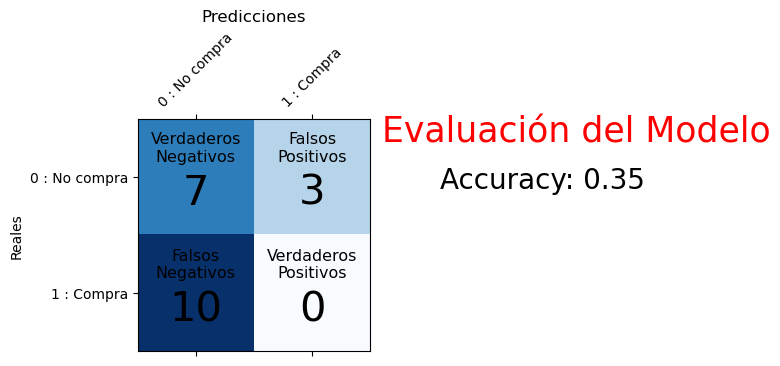

In [38]:
import matplotlib.pyplot as plt


def metricas(clases_reales, clases_predichas):
    """Calcular las métricas utilizando sklearn"""
    matriz = confusion_matrix(clases_reales, clases_predichas)
    accuracy = accuracy_score(clases_reales, clases_predichas)
    return matriz, accuracy

def visualiza_metricas(clases_reales, clases_predichas, titulo):
    """Visualiza la matriz de confusión y métricas"""
    
    matriz, accuracy = metricas(clases_reales, clases_predichas)

    plt.figure(figsize=(3,3))
    matriz_df = pd.DataFrame(
        matriz,
        columns=["0 : No compra", "1 : Compra"],
        index=["0 : No compra", "1 : Compra"]
    )
    
    plt.matshow(matriz_df, cmap="Blues", vmin=0, vmax=matriz_df.values.max(), fignum=1)
    plt.title("Predicciones")
    plt.ylabel("Reales")
    plt.xticks(range(len(matriz_df.columns)), matriz_df.columns, rotation=45)
    plt.yticks(range(len(matriz_df.index)), matriz_df.index)
    
    etiquetas = (
        ("Verdaderos\nNegativos", "Falsos\nPositivos"),
        ("Falsos\nNegativos", "Verdaderos\nPositivos")
    )

    for i in range(len(matriz_df.columns)):
        for j in range(len(matriz_df.columns)):
            plt.text(i, j+0.14, str(matriz_df.iloc[j, i]),
                     fontsize=30, ha="center", va="center")
            plt.text(i, j-0.25, etiquetas[j][i],
                     fontsize=11.5, ha="center", va="center")
    
    plt.text(1.60, -0.30, titulo, fontsize=25, c="red")
    plt.text(2.1, 0.10, "Accuracy: %0.2f" % accuracy, fontsize=20)
    plt.show()
    print("\n" * 5)

# 1. Predecir
y_pred = modelo.predict(X_test)

# 2. Visualizar resultados
visualiza_metricas(y_test, y_pred, "Evaluación del Modelo")